<img src="Figures/xx_model-en-345-0_modezai_2025022500_12_15_1.png" alt="A typical dense neural network architecture." width="1000"/>
<img src="Figures/xx_model-en-345-0_modezai_2025022500_84_15_1.png" alt="A typical dense neural network architecture." width="1000"/>

In [ ]:
from copy import deepcopy

import torch
import torch.optim
import torch.nn
import torch.nn.functional as F
from torch.autograd import grad

import numpy as np

from tqdm.notebook import tqdm

import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(42)

In [3]:
n_train = 100
noise_level = 0.2

# Linear Part

In [4]:
true_beta1 = torch.randn(1)
true_beta0 = torch.randn(1)

## Linear regression

In [5]:
x_train = torch.rand(n_train) * 5 - 2.5
y_train = true_beta1 * x_train + true_beta0 + noise_level * torch.randn(n_train)

In [6]:
x_plot = torch.linspace(-3, 3, 10001)
y_plot = true_beta1 * x_plot + true_beta0

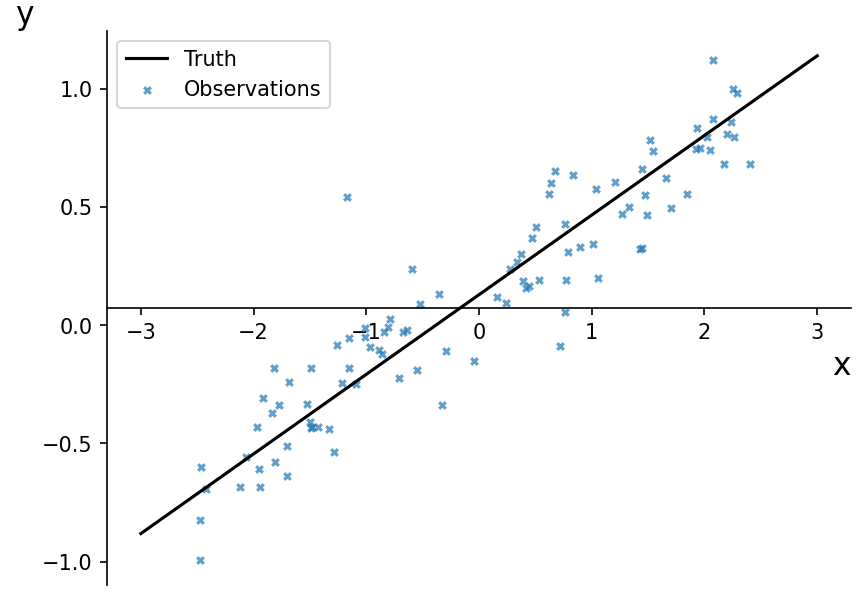

In [7]:
fig, ax = plt.subplots(dpi=150)

ax.spines.left.set_position(("axes", 0.))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position('center')
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(x_plot, y_plot, c="black", ls="-", label="Truth", zorder=3)
ax.scatter(x_train, y_train, marker="x", alpha=0.7, c="C0", s=10, label="Observations", zorder=2)

ax.set_ylabel("y", loc="top", size=15, rotation=0)
ax.set_xlabel("x", loc="right", size=15, rotation=0)
ax.legend()

### Least squares solution

In [8]:
x_input = torch.stack((torch.ones(n_train), x_train), dim=1)
y_output = y_train.unsqueeze(1)

In [9]:
xtx = x_input.T@x_input
xty = x_input.T@y_output

betas_lin = torch.linalg.inv(xtx)@xty

In [10]:
print("True beta: ", np.array((true_beta0.item(), true_beta1.item())))
print("Pred beta: ", betas_lin.squeeze(dim=1).numpy())

True beta:  [0.12880941 0.33669037]
Pred beta:  [0.12548454 0.31356648]


In [11]:
y_pred = betas_lin[1] * x_plot + betas_lin[0]

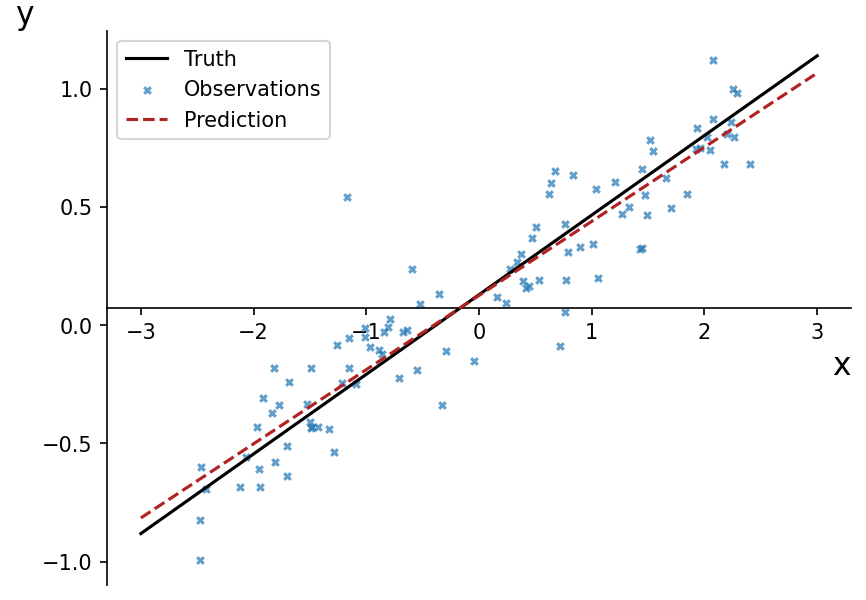

In [12]:
fig, ax = plt.subplots(dpi=150)

ax.spines.left.set_position(("axes", 0.))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position('center')
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(x_plot, y_plot, c="black", ls="-", label="Truth", zorder=3)
ax.scatter(x_train, y_train, marker="x", alpha=0.7, c="C0", s=10, label="Observations", zorder=2)
ax.plot(x_plot, y_pred, c="firebrick", ls="--", label="Prediction", zorder=3)

ax.set_ylabel("y", loc="top", size=15, rotation=0)
ax.set_xlabel("x", loc="right", size=15, rotation=0)
ax.legend()

## Classification

In [14]:
threshold = 0.

In [15]:
x_train = torch.rand(n_train) * 5 - 2.5
y_train = ((true_beta1 * x_train + true_beta0 + noise_level * torch.randn(n_train)) > threshold).float()

In [16]:
x_plot = torch.linspace(-3, 3, 10001)
y_plot = ((true_beta1 * x_plot + true_beta0) > threshold).float()

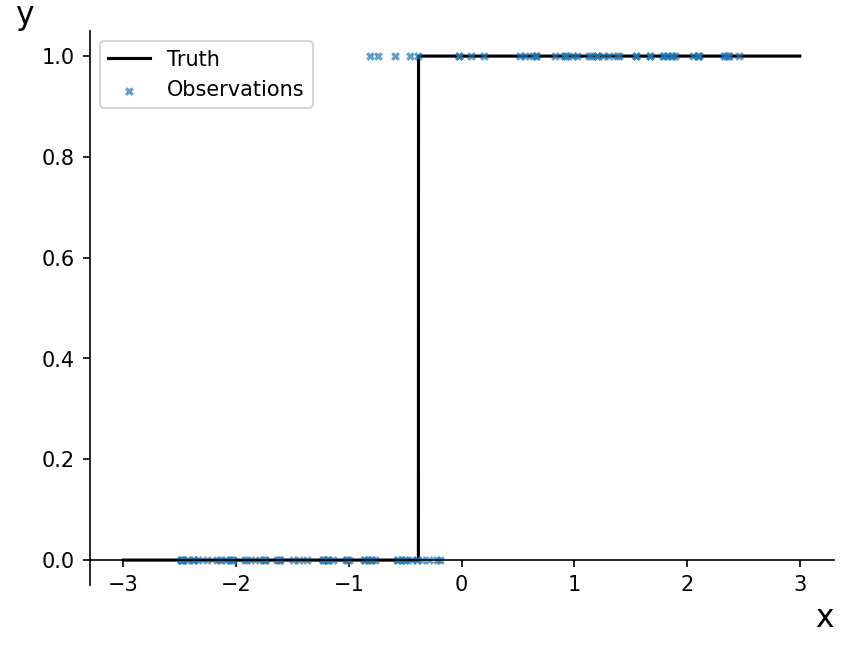

In [17]:
fig, ax = plt.subplots(dpi=150)

ax.spines.left.set_position(("axes", 0.))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position('zero')
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(x_plot, y_plot, c="black", ls="-", label="Truth", zorder=1)
ax.scatter(x_train, y_train, marker="x", alpha=0.7, c="C0", s=10, label="Observations", zorder=2)

ax.set_ylabel("y", loc="top", size=15, rotation=0)
ax.set_xlabel("x", loc="right", size=15, rotation=0)
ax.legend()

### Least-squares solution

In [18]:
x_input = torch.stack((torch.ones(n_train), x_train), dim=1)
y_output = y_train.unsqueeze(1) * 2 - 1

In [19]:
xtx = x_input.T@x_input
xty = x_input.T@y_output

betas_class = torch.linalg.inv(xtx)@xty

In [20]:
y_pred = (betas_class[1] * x_plot + betas_class[0]) / 2 + 0.5

In [21]:
print("LS accuracy: ", (y_plot == (y_pred > 0.5).float()).float().mean().item())

LS accuracy:  0.9524047374725342


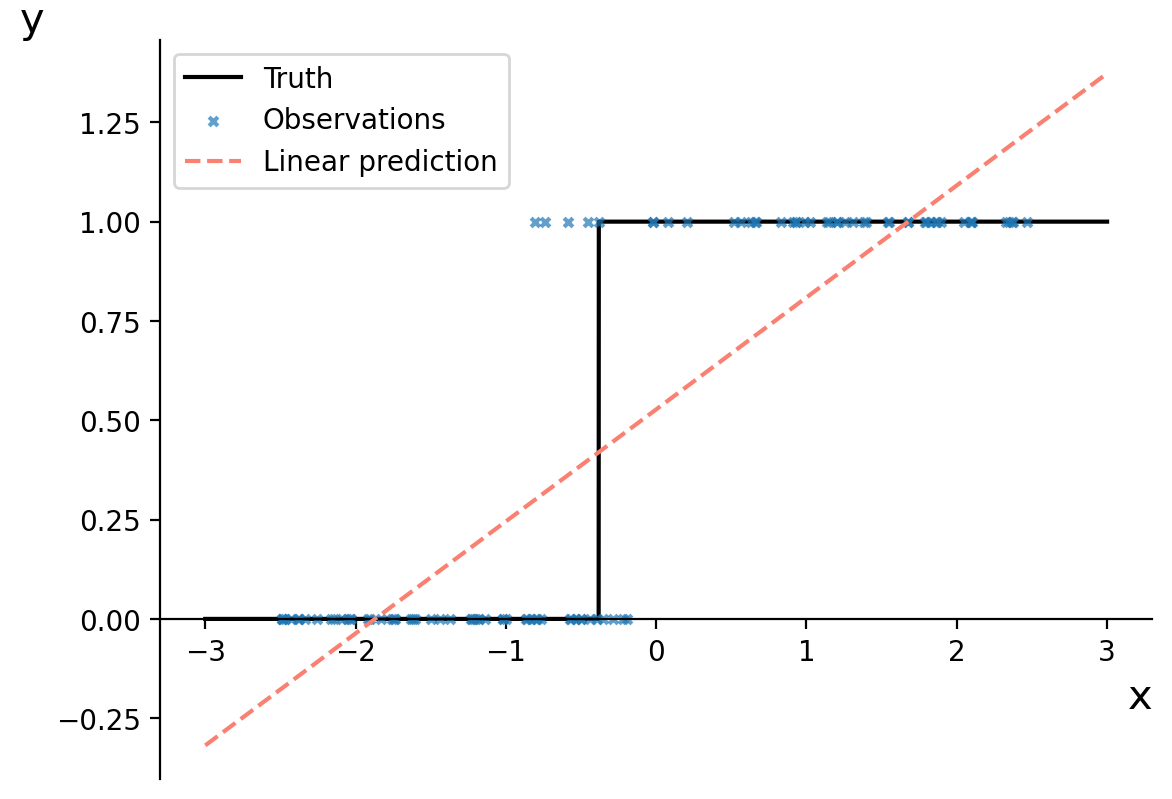

In [23]:
fig, ax = plt.subplots(dpi=200)

ax.spines.left.set_position(('axes', 0))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position('zero')
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(x_plot, y_plot, c="black", ls="-", label="Truth", zorder=1)
ax.scatter(x_train, y_train, marker="x", alpha=0.7, c="C0", s=10, label="Observations", zorder=2)
ax.plot(x_plot, y_pred, c="salmon", ls="--", label="Linear prediction", zorder=3)

ax.set_ylabel("y", loc="top", size=15, rotation=0)
ax.set_xlabel("x", loc="right", size=15, rotation=0)
ax.legend()

### Logistic regression

In [24]:
n_iters = 50000

In [25]:
betas_logistic = torch.nn.Parameter(torch.zeros(2))
betas_optim = torch.optim.SGD([betas_logistic], lr=1E-3)

#### Use autograd

In [26]:
pred_train = x_input@betas_logistic
pred_train = torch.sigmoid(pred_train)
loss = F.binary_cross_entropy(pred_train, y_train)
loss.backward()
#print("Grad: ", grad(loss, [betas_logistic])[0])

In [27]:
pbar = tqdm(range(n_iters))

for _ in pbar:
    betas_optim.zero_grad()
    pred_train = x_input@betas_logistic
    pred_train = torch.sigmoid(pred_train)
    loss = F.binary_cross_entropy(pred_train, y_train)
    loss = loss.mean()
    loss.backward()
    betas_optim.step()
    
    pbar.set_postfix(loss=loss.item())

  0%|          | 0/50000 [00:00<?, ?it/s]

In [28]:
with torch.no_grad():
    y_pred_class = torch.sigmoid(x_plot*betas_logistic[1]+betas_logistic[0])

In [29]:
print("LS accuracy: ", (y_plot == (y_pred > 0.5).float()).float().mean().item())
print("Class accuracy: ", (y_plot == (y_pred_class > 0.5).float()).float().mean().item())

LS accuracy:  0.9524047374725342
Class accuracy:  0.9664033651351929


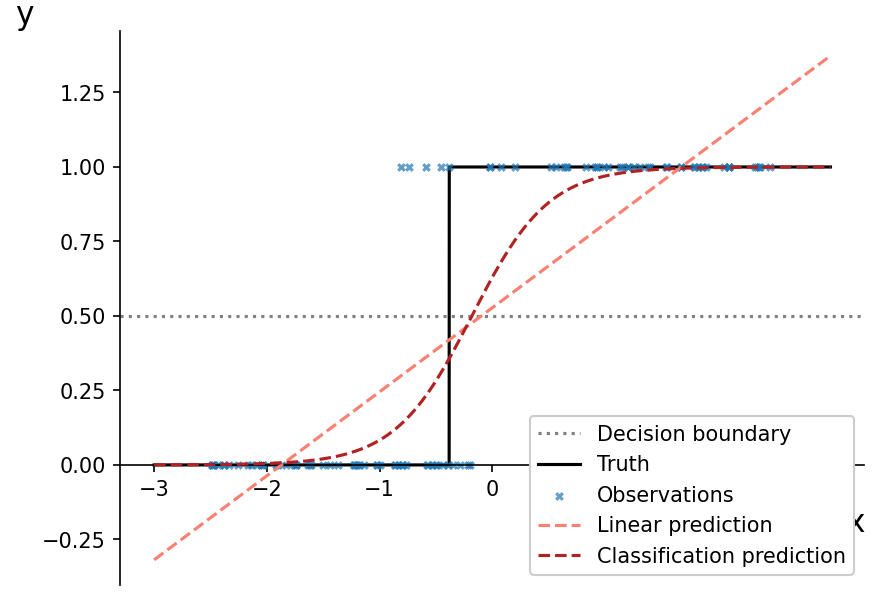

In [30]:
fig, ax = plt.subplots(dpi=150)

ax.spines.left.set_position(('axes', 0))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position('zero')
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.axhline(y=0.5, c="0.5", ls=":", label="Decision boundary")

ax.plot(x_plot, y_plot, c="black", ls="-", label="Truth", zorder=1)
ax.scatter(x_train, y_train, marker="x", alpha=0.7, c="C0", s=10, label="Observations", zorder=2)
ax.plot(x_plot, y_pred, c="salmon", ls="--", label="Linear prediction", zorder=3)
ax.plot(x_plot, y_pred_class, c="firebrick", ls="--", label="Classification prediction", zorder=3)

ax.set_ylabel("y", loc="top", size=15, rotation=0)
ax.set_xlabel("x", loc="right", size=15, rotation=0)
ax.legend(framealpha=1.)

# Neural network

<img src="./Figures/neural_net.png" alt="A typical dense neural network architecture." width="1000"/>

## Activation functions

In [33]:
x_plot = torch.linspace(-5, 5, 10001)

In [34]:
funcs = {
    "ReLU": torch.nn.ReLU(),
    "Sigmoid": torch.nn.Sigmoid(),
    "GeLU": torch.nn.GELU()
}

funcs_pred = dict()
funcs_grad = dict()

for key, func in funcs.items():
    x_input = x_plot.clone().requires_grad_(True)
    curr_pred = func(x_input)
    curr_grad = grad(curr_pred.sum(), [x_input])[0]
    funcs_pred[key] = curr_pred.detach()
    funcs_grad[key] = curr_grad

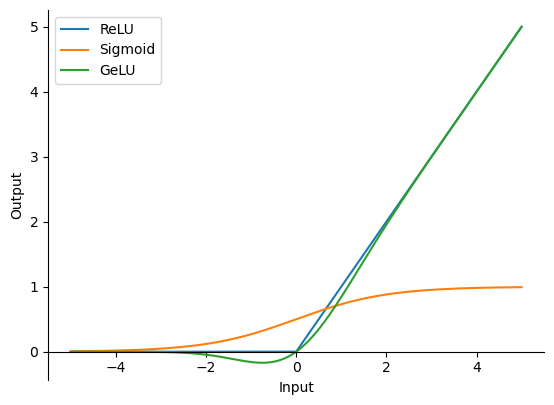

In [35]:
fig, ax = plt.subplots(dpi=100)

ax.spines.left.set_position(('axes', 0))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position('zero')
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

for name, curr_pred in funcs_pred.items():
    ax.plot(x_plot, curr_pred, label=name)
ax.set_xlabel("Input")
ax.set_ylabel("Output")
ax.legend()

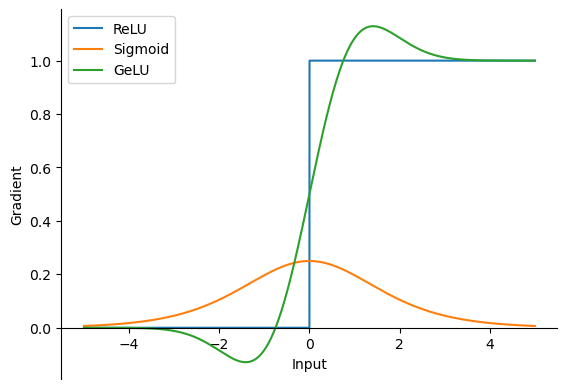

In [36]:
fig, ax = plt.subplots(dpi=100)

ax.spines.left.set_position(('axes', 0))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position('zero')
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

for name, curr_grad in funcs_grad.items():
    ax.plot(x_plot, curr_grad, label=name)
ax.set_xlabel("Input")
ax.set_ylabel("Gradient")
ax.legend()

# Train neural network

In [37]:
n_train = 100
n_val = 1000
n_iters = 10000

In [38]:
def true_func(x):
    first_part = x * 0.5 + 0.3
    sig_part = torch.sigmoid(x * 0.2)
    sin_part = torch.sin(x * 10. / torch.pi)
    relu_part = torch.relu(x * 1 + 0.1)
    return sin_part * first_part * sig_part + relu_part

In [39]:
x_train = torch.rand(n_train) * 6 - 3
y_train = true_func(x_train + torch.randn(n_train) * 0.2)

In [40]:
x_val = torch.rand(n_val) * 6 - 3
y_val = true_func(x_val)

In [41]:
y_plot = true_func(x_plot)

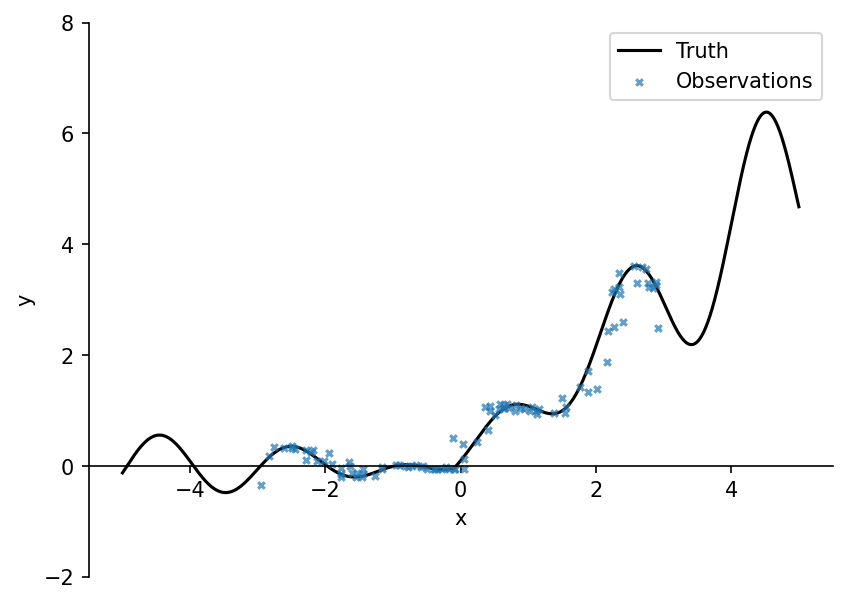

In [42]:
fig, ax = plt.subplots(dpi=150)

ax.spines.left.set_position(('axes', 0))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position('zero')
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(x_plot, y_plot, c="black", ls="-", label="Truth", zorder=1)
ax.scatter(x_train, y_train, marker="x", alpha=0.7, c="C0", s=10, label="Observations", zorder=2)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-2, 8)
ax.legend()

## Quite small NN

In [43]:
nn_first = torch.nn.Sequential(
    torch.nn.Linear(1, 4, bias=True),
    torch.nn.GELU(),
    torch.nn.Linear(4, 1, bias=True)
)

nn_optim = torch.optim.Adam(nn_first.parameters(), lr=1E-3)

In [44]:
pbar = tqdm(range(n_iters))

loss_curves = {"train": [], "val": []}

for i in pbar:
    nn_optim.zero_grad()
    pred_train = nn_first(x_train[:, None]).squeeze(1)
    loss = (pred_train-y_train).pow(2)
    loss = loss.mean()
    loss.backward()
    nn_optim.step()
    
    if i % 100 == 0:
        with torch.no_grad():
            pred_val = nn_first(x_val[:, None]).squeeze(1)
            loss_val = (pred_val-y_val).pow(2)
            loss_val = loss_val.mean()
            
    loss_curves["train"].append(loss.item())
    loss_curves["val"].append(loss_val.item())
    
    pbar.set_postfix(train_loss=loss.item(), val_loss=loss_val.item())

  0%|          | 0/10000 [00:00<?, ?it/s]

### Plot loss

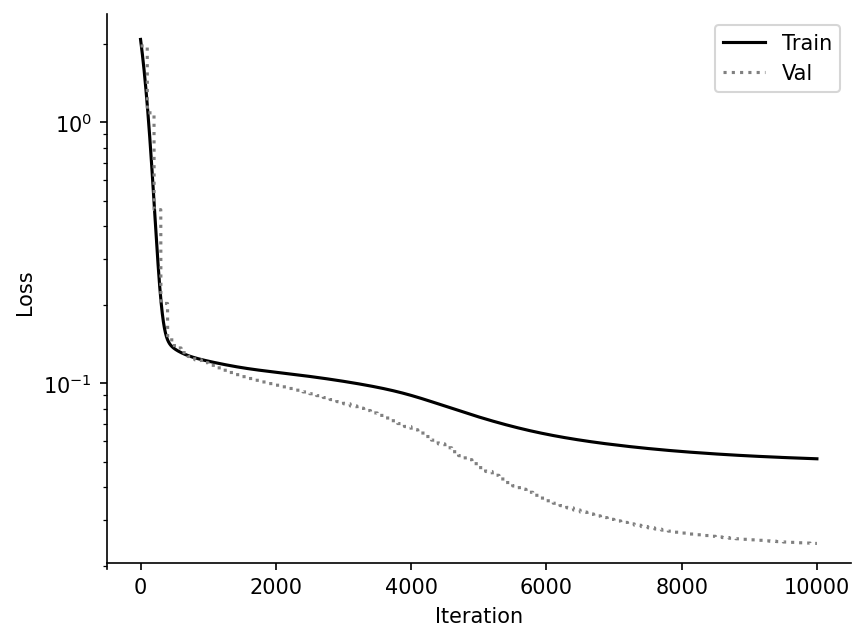

In [45]:
fig, ax = plt.subplots(dpi=150)

ax.spines.left.set_position(('axes', 0))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position(('axes', 0.01))
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(loss_curves["train"], c="black", ls="-", label="Train")
ax.plot(loss_curves["val"], c="0.5", ls=":", label="Val")

ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")

ax.legend()

### Plot prediction

In [46]:
with torch.no_grad():
    y_pred = nn_first(x_plot[:, None]).squeeze(1)

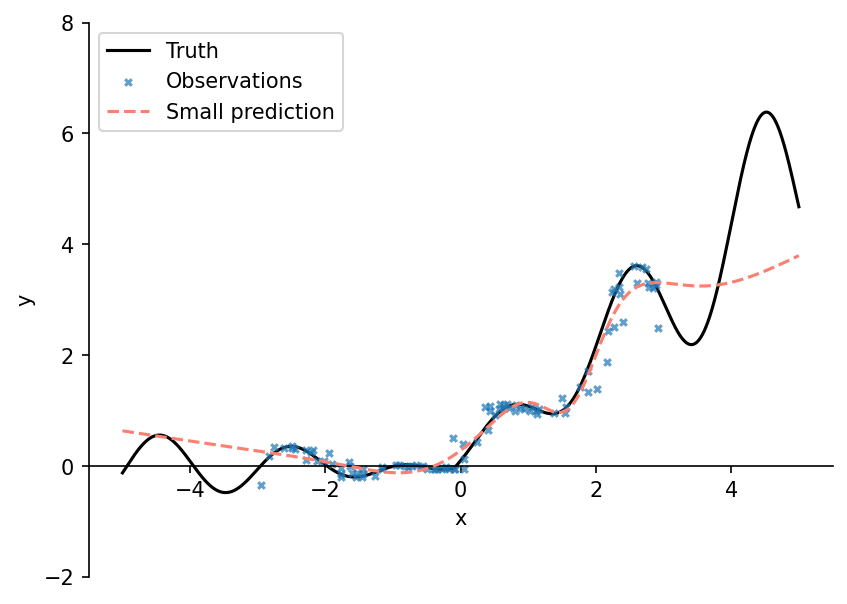

In [47]:
fig, ax = plt.subplots(dpi=150)

ax.spines.left.set_position(('axes', 0))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position('zero')
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(x_plot, y_plot, c="black", ls="-", label="Truth", zorder=1)
ax.scatter(x_train, y_train, marker="x", alpha=0.7, c="C0", s=10, label="Observations", zorder=2)
ax.plot(x_plot, y_pred, c="salmon", ls="--", label="Small prediction", zorder=3)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-2, 8)
ax.legend()

## Bigger + Deeper NN (overfitting)

In [48]:
nn_bigger = torch.nn.Sequential(
    torch.nn.Linear(1, 256, bias=True),
    torch.nn.GELU(),
    torch.nn.Linear(256, 256, bias=True),
    torch.nn.GELU(),
    torch.nn.Linear(256, 1, bias=True)
)

nn_optim = torch.optim.Adam(nn_bigger.parameters(), lr=1E-4)

In [96]:
pbar = tqdm(range(n_iters))

loss_curves = {"train": [], "val": []}

best_val = torch.inf
best_model = None

for i in pbar:
    nn_optim.zero_grad()
    pred_train = nn_bigger(x_train[:, None]).squeeze(1)
    loss = (pred_train-y_train).pow(2)
    loss = loss.mean()
    loss.backward()
    nn_optim.step()
    
    if i % 100 == 0:
        with torch.no_grad():
            pred_val = nn_bigger(x_val[:, None]).squeeze(1)
            loss_val = (pred_val-y_val).pow(2)
            loss_val = loss_val.mean().item()
            
        if loss_val < best_val:
            best_model = deepcopy(nn_bigger)
            best_val = loss_val
            
    loss_curves["train"].append(loss.item())
    loss_curves["val"].append(loss_val)
    
    pbar.set_postfix(train_loss=loss.item(), val_loss=loss_val)

  0%|          | 0/10000 [00:00<?, ?it/s]

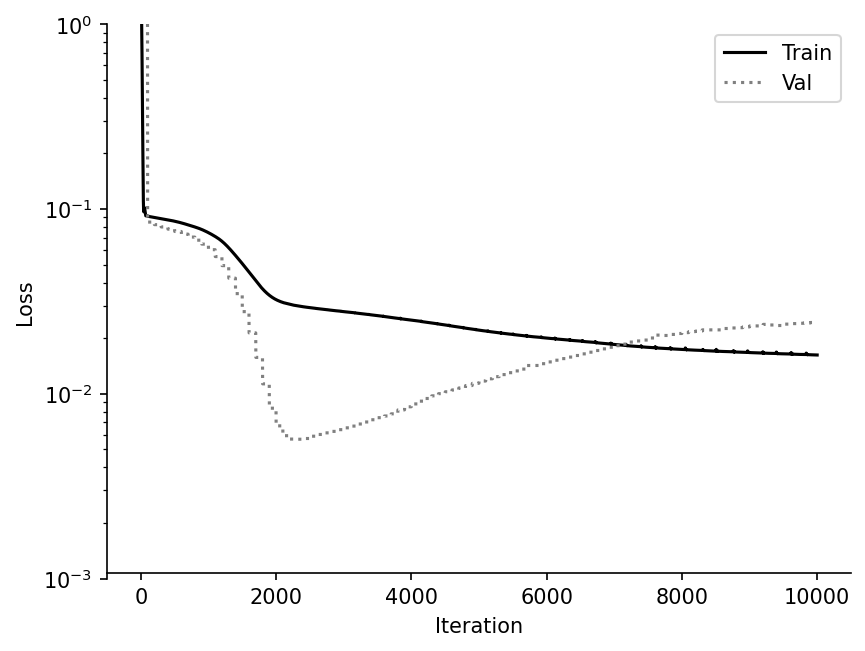

In [98]:
fig, ax = plt.subplots(dpi=150)

ax.spines.left.set_position(('axes', 0))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position(('axes', 0.01))
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(loss_curves["train"], c="black", ls="-", label="Train")
ax.plot(loss_curves["val"], c="0.5", ls=":", label="Val")

ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_ylim(1E-3, 1)

ax.legend()

### Plot prediction

In [99]:
with torch.no_grad():
    y_pred_best = best_model(x_plot[:, None]).squeeze(1)
    y_pred_bigger = nn_bigger(x_plot[:, None]).squeeze(1)

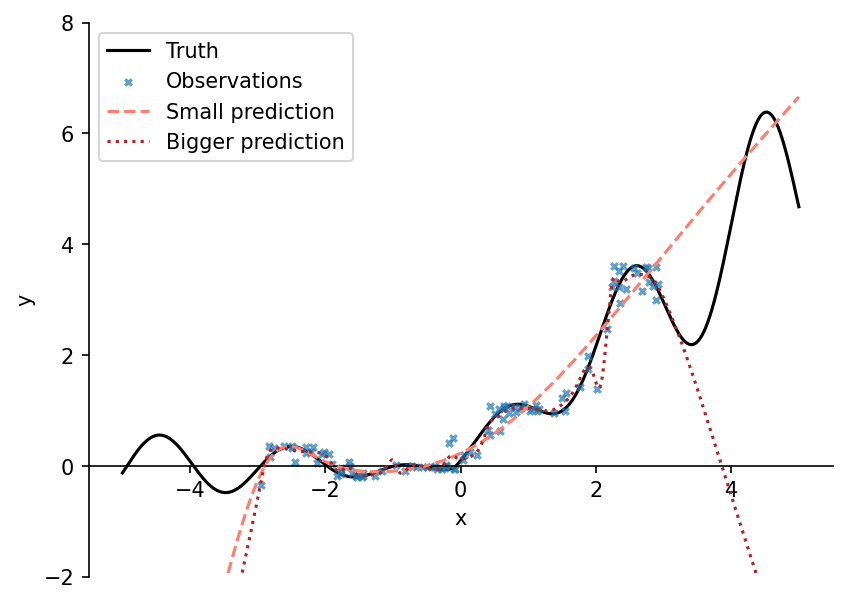

In [100]:
fig, ax = plt.subplots(dpi=150)

ax.spines.left.set_position(('axes', 0))
ax.spines.right.set_color('none')
ax.spines.bottom.set_position('zero')
ax.spines.top.set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(x_plot, y_plot, c="black", ls="-", label="Truth", zorder=1)
ax.scatter(x_train, y_train, marker="x", alpha=0.7, c="C0", s=10, label="Observations", zorder=2)
ax.plot(x_plot, y_pred, c="salmon", ls="--", label="Small prediction", zorder=3)
ax.plot(x_plot, y_pred_bigger, c="firebrick", ls=":", label="Bigger prediction", zorder=3)
# ax.plot(x_plot, y_pred_best, c="firebrick", ls="-", label="Best bigger prediction", zorder=3)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-2, 8)
ax.legend()

# Final loss

In [101]:
print("Small: ", (y_pred-y_plot).pow(2).mean().item())
print("Bigger: ", (y_pred_bigger-y_plot).pow(2).mean().item())
#print("Best: ", (y_pred_best-y_plot).pow(2).mean().item())

Small:  5.624170780181885
Bigger:  17.453290939331055
